# HOMEWORK 1: AI ASSISTED PYTHON PROGRAMMING

In this homework, you are encouraged to use an AI assist to solve the problem.

Below, you will find the sequential model that we discussed in class. You may recall that species S2 is convex, it rises and then declines.

**Your assignment**
1. *Implementation* Write a function that finds values of k1 and k2 such that S2 peaks at a desired value. Remember that you need to document the function arguments and result and describe what it does. You also need at least one test. You should try to make the algorithm efficient. Remember to include a test for the values returned (e.g., returns floats).
2. *Verfication of Results*. Simulate with values found by your test case to ensure the algorithm's correct operation.
3. *Analysis*. Simulate for a peak times at 1s, 2s, 3s. How are k1, k2 being changed to move the peak to be later in time? Why?


**Rubric (100 pts)**
* Function documentation (input types, output types, description): 20
* Has a meaningful test: 20
* Function works correctly: 50
* Function is efficient (better than a grid search): 10


In [1]:
try:
    import tellurium as te
except:
    !pip install -q tellurium
    !pip install --upgrade numpy
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Tuple

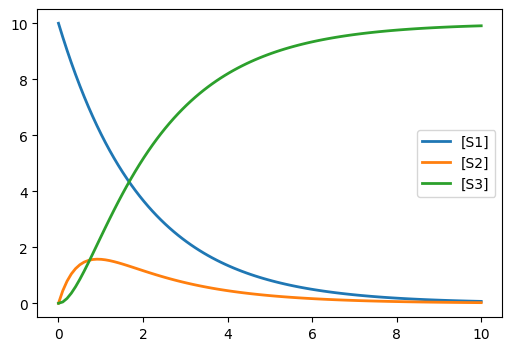

In [2]:
def getModel(k1, k2):
    return f"""
    S1 -> S2; k1*S1
    S2 -> S3; k2*S2

    S1 = 10
    S2 = 0
    k1 = {k1} # Adjust this value
    k2 = {k2} # Adjust this value
    """
rr = te.loada(getModel(k1=0.5, k2=2))
data = rr.simulate(0, 10, 100)
rr.plot()

# Q1: Implementation

Prompt 1: Species S2 is convex, rises and then declines. Please write a function that finds values of k1 and k2 such that S2 peaks at a desired value. You should document the function arguments and result and describe what it does. Provide at least one test that returns a value of True or False.

This generated code that did an exhausted grid search. This was inefficient and likely could not find the correct value.

Prompt 2: Modify the search algorithm so that it uses gradient descent on the parameters k1, k2. That is, if increasing k1 (or k2) causes diff to decrease, then a further increase is done. If it causes diff to increase, then k1 is decreased by half the fraction that was used previously.

This generated code that had a bug in which the learning rate was reset on each loop iteration. I fixed this manually.

In [3]:
def find_k1_k2_for_S2_peak_time(desired_peak_time: float,
        learning_rate:float =0.1, iterations:int =100,
        tolerance:float=0.01, initial_k1:float=0.5,
        initial_k2:float=2) -> Union[None, Tuple[float, float]]:
    """
    Finds k1 and k2 values for the given Tellurium model such that species S2
    reaches its peak at a desired time using a gradient descent-like approach.

    Args:
        desired_peak_time (float): The target time for the peak of species S2.
        learning_rate (float): The initial step size for k1 and k2 adjustments.
        iterations (int): The maximum number of iterations for the optimization.
        tolerance (float): The desired level of accuracy for the peak time.
        initial_k1 (float): The initial value for k1.
        initial_k2 (float): The initial value for k2.

    Returns:
        tuple: A tuple containing the found k1 and k2 values (k1, k2),
               or None if a solution is not found within the given iterations.
    """
    k1 = initial_k1
    k2 = initial_k2
    best_k1 = k1
    best_k2 = k2

    def get_peak_time(current_k1, current_k2):
        model = getModel(current_k1, current_k2)
        try:
            rr = te.loada(model)
            # Simulate with more points to get a more accurate peak time
            data = rr.simulate(0, 10, 1000)
            s2_values = data['[S2]']
            time_values = data['time']
            peak_index = np.argmax(s2_values)
            current_peak_time = time_values[peak_index]
            return current_peak_time
        except Exception as e:
            # Return a large difference to discourage invalid parameters
            return float('inf')

    def get_peak_time_diff(current_k1, current_k2):
        current_peak_time = get_peak_time(current_k1, current_k2)
        return abs(current_peak_time - desired_peak_time)

    diff = get_peak_time_diff(k1, k2)
    best_diff = diff

    delta_k1 = learning_rate
    delta_k2 = learning_rate

    for i in range(iterations):
        last_diff = diff

        # --- Update k1 ---
        diff_plus_k1 = get_peak_time_diff(k1 + delta_k1, k2)
        diff_minus_k1 = get_peak_time_diff(k1 - delta_k1, k2)

        if diff_plus_k1 < diff:
            k1 += delta_k1
            diff = diff_plus_k1
            delta_k1 *= 1.1 # Increase step size if improvement
        elif diff_minus_k1 < diff:
            k1 -= delta_k1
            diff = diff_minus_k1
            delta_k1 *= 1.1 # Increase step size if improvement
        else:
            delta_k1 *= 0.5 # Reduce step size if no improvement

        # --- Update k2 ---
        diff_plus_k2 = get_peak_time_diff(k1, k2 + delta_k2)
        diff_minus_k2 = get_peak_time_diff(k1, k2 - delta_k2)

        if diff_plus_k2 < diff:
            k2 += delta_k2
            diff = diff_plus_k2
            delta_k2 *= 1.1 # Increase step size if improvement
        elif diff_minus_k2 < diff:
            k2 -= delta_k2
            diff = diff_minus_k2
            delta_k2 *= 1.1 # Increase step size if improvement
        else:
            delta_k2 *= 0.5 # Reduce step size if no improvement

        # print(f"Iteration {i+1}: k1={k1:.4f}, k2={k2:.4f}, diff={diff:.4f}, delta_k1={delta_k1:.4f}, delta_k2={delta_k2:.4f}")

        if diff < best_diff:
            best_diff = diff
            best_k1 = k1
            best_k2 = k2

        if diff < desired_peak_time * tolerance:
            print(f"Converged after {i+1} iterations. Final diff: {diff:.4f}")
            return best_k1, best_k2

        # Stop if no significant progress
        if abs(diff - last_diff) < desired_peak_time * tolerance * 0.1 and i > 10:
             print(f"No significant progress after {i+1} iterations. Final diff: {diff:.4f}")
             return best_k1, best_k2


    print(f"Did not converge within {iterations} iterations. Best diff: {best_diff:.4f}")
    if best_diff < desired_peak_time * tolerance * 5: # Return best if within 5*tolerance
         return best_k1, best_k2
    else:
        return None

# TESTS
k1, k2 = find_k1_k2_for_S2_peak_time(3.1, initial_k1=1, initial_k2=1)
assert(isinstance(k1, float))
assert(isinstance(k2, float))
print("OK!")

TypeError: unsupported operand type(s) for |: 'types.GenericAlias' and 'NoneType'

# Q2: Verification

In [ ]:
desired_time = 3.0
k1, k2 = find_k1_k2_for_S2_peak_time(desired_time)

In [ ]:
# Confirming simulation
rr = te.loada(getModel(k1=0.23, k2=0.46))
data = rr.simulate(0, 10, 100)
plt.plot(data['time'], data['[S2]'])
plt.plot([desired_time, desired_time], [0, 10], 'r--', label='Desired Time')
_ = plt.legend(["S2", "desired peak time"])

The peak time is 3, as desired.

# Q3: Analysis



In [ ]:
result_dct = {}
for peak_time in [1, 2, 3]:
    k1, k2 = find_k1_k2_for_S2_peak_time(peak_time, initial_k1=1, initial_k2=1)
    result_dct[peak_time] = (k1, k2)

In [ ]:
k1_arr = np.array([r[0] for r in result_dct.values()])
k2_arr = np.array([r[1] for r in result_dct.values()])
plt.plot([1, 2, 3], k1_arr, label='k1')
plt.plot([1, 2, 3], k2_arr)
plt.legend(["k1", "k2"])
plt.xlabel("Peak time")
plt.ylabel("Kinetic Value")
plt.show()

Making the peak time later results in *decreasing* both $k_1$ and $k_2$. This is so that the time of the peak happens later because we are slowing the rate at which reactions take place. Note that $k_1 < k_2$. This must be the cause to increase the concentration of $S_2$.